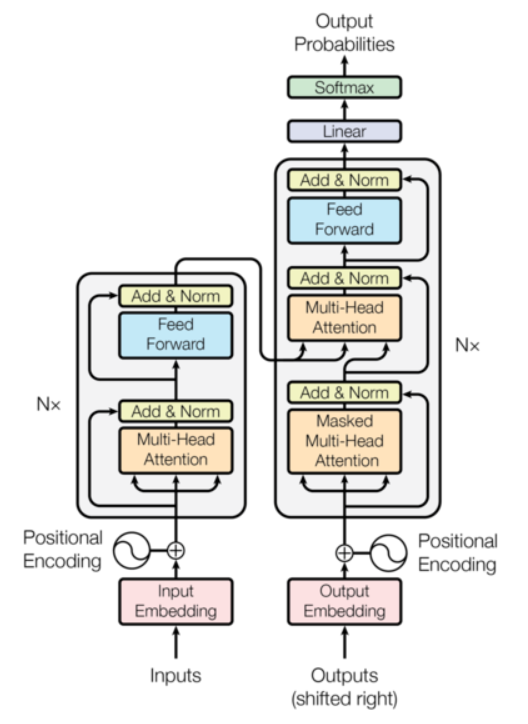

# Transformer

In [1]:
import torch
import torch.nn as nn
import math
import torch.nn.functional as F

## Positional Encoding

Positional Encoding:
$$
PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

$$
PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

In [2]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Tạo véc-tơ giá trị postion encoding, tử số và mẫu số trong ngoặc
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        # Lưu lại model để có thể di chuyển lên GPU.
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

## Embedding Layer


Công thức:
$$
\text{Output} = \text{Embedding} \times \sqrt{d_{\text{model}}} + \text{PositionalEncoding}
$$

In [3]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

## Multihead-Attention Layer

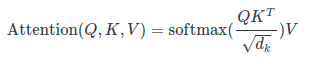

In [4]:
def attention(query, key, value, mask=None, dropout=None):
    """
    Hàm Scaled Dot-Product Attention DUY NHẤT.
    mask: Ma trận chứa 1 (cho phép nhìn) và 0 (bị che giấu).
    """
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    
    if mask is not None:
        # TÌM CÁC VỊ TRÍ BẰNG 0 ĐỂ PHẠT -1e9
        scores = scores.masked_fill(mask == 0, -1e9)
        
    p_attn = F.softmax(scores, dim=-1)
    
    if dropout is not None:
        p_attn = dropout(p_attn)
        
    return torch.matmul(p_attn, value), p_attn

In [5]:
def subsequent_mask(size):
    """
    Tạo mặt nạ che tương lai (Look-ahead mask).
    Trả về: Ma trận tam giác dưới chứa toàn số 1, tam giác trên chứa số 0.
    """
    attn_shape = (1, size, size)
    # torch.triu tạo tam giác trên.
    # So sánh == 0 sẽ lật ngược lại, biến tam giác dưới thành True (1), trên thành False (0)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1)
    return (subsequent_mask == 0).type(torch.uint8)

class Batch:
    """
    Đóng gói dữ liệu và tự động sinh src_mask, tgt_mask dạng số (0 và 1).
    """
    def __init__(self, src, tgt=None, pad=0):
        self.src = src
        # mask = 1 nếu khác pad, mask = 0 nếu là pad
        self.src_mask = (src != pad).unsqueeze(-2).type(torch.uint8)
        
        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            
            # Tạo tgt_mask kết hợp cả che pad và che tương lai
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        # 1. Padding mask (1 là từ thật, 0 là pad)
        tgt_mask = (tgt != pad).unsqueeze(-2).type(torch.uint8)
        # 2. Look-ahead mask (1 là quá khứ/hiện tại, 0 là tương lai)
        # Dùng toán tử & để kết hợp: Vị trí nào thỏa mãn CẢ HAI mới bằng 1
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(tgt_mask.data)
        return tgt_mask

In [6]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        """
        Khởi tạo Multi-Head Attention.
        h: Số lượng head (ví dụ: 8).
        d_model: Kích thước vector biểu diễn (ví dụ: 256 hoặc 512).
        """
        super(MultiHeadedAttention, self).__init__()
        
        # Đảm bảo d_model có thể chia đều cho số lượng head
        assert d_model % h == 0
        
        self.d_k = d_model // h
        self.h = h
        
        # Tạo 4 lớp Linear: 3 lớp đầu dùng để chiếu Query, Key, Value; 1 lớp cuối cho Output.
        self.linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(4)])
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        nbatches = query.size(0)
        
        # 1. Xử lý Mask: Thêm 1 chiều (dimension) để broadcast qua h heads
        if mask is not None:
            # Mask từ (batch_size, seq_len, seq_len) -> (batch_size, 1, seq_len, seq_len)
            mask = mask.unsqueeze(1)

        # 2. Chiếu tuyến tính (Linear Projections) và chia thành h heads
        # Chuyển đổi kích thước: (batch_size, seq_len, d_model) 
        # => (batch_size, seq_len, h, d_k) => (batch_size, h, seq_len, d_k)
        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears[:3], (query, key, value))
        ]

        # 3. Gọi hàm Attention cốt lõi trên tất cả các heads
        # Lưu ý: Hàm attention() này là hàm duy nhất chúng ta định nghĩa ở bước trước,
        # nó sẽ tự tìm các vị trí mask == 0 để điền -1e9.
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)

        # 4. Nối (Concatenate) các heads lại với nhau
        # Chuyển đổi: (batch_size, h, seq_len, d_k) => (batch_size, seq_len, d_model)
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)

        # 5. Phép chiếu tuyến tính cuối cùng
        return self.linears[-1](x)

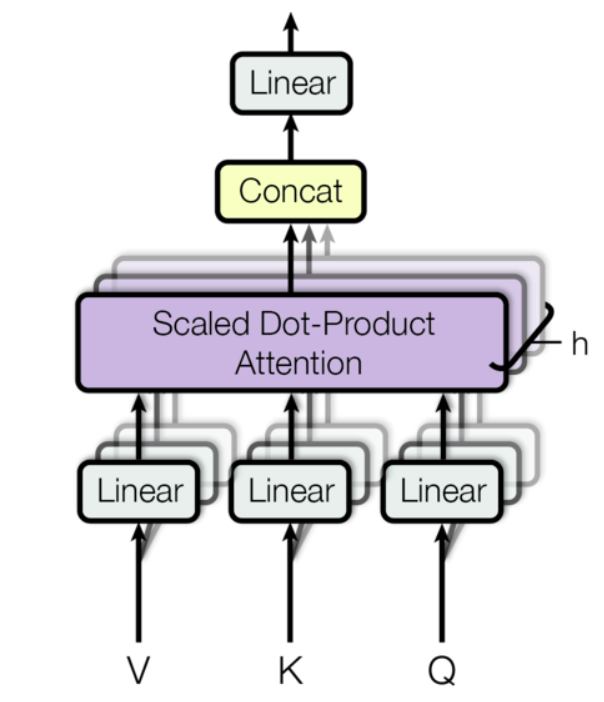

Mỗi head trong attention sẽ nhận kích thước d_k bằng nhau. Trước khi thông tin đưa vào các head, ta cần giảm kích thước đầu vào xuống.

## Position Feed Forward

In [7]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

## Layer Norm

In [8]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

## Sublayer Connection

In [9]:
class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """

    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))

## Encoder - Decoder

In [10]:
import copy

def clones(module, N):
    "Tạo ra N lớp giống hệt nhau."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [11]:
class EncoderLayer(nn.Module):
    """
    EncoderLayer bao gồm 2 sub-layer: 
    1. Multi-Head Self-Attention
    2. Position-wise Feed Forward
    """
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        # Dùng 2 SublayerConnection cho 2 sub-layer ở trên
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        # Sub-layer 1: Self-Attention (Query = Key = Value = x)
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        
        # Sub-layer 2: Feed Forward
        return self.sublayer[1](x, self.feed_forward)

class Encoder(nn.Module):
    """
    Encoder cốt lõi là một chồng (stack) gồm N lớp EncoderLayer
    """
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size) # Chuẩn hóa lần cuối cùng

    def forward(self, x, mask):
        """Cho đầu vào (x) đi qua lần lượt N lớp."""
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

In [12]:
class DecoderLayer(nn.Module):
    """
    DecoderLayer bao gồm 3 sub-layer:
    1. Masked Multi-Head Self-Attention (Chỉ nhìn quá khứ)
    2. Multi-Head Cross-Attention (Nhìn sang Encoder)
    3. Position-wise Feed Forward
    """
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        # Dùng 3 SublayerConnection cho 3 sub-layer
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        """
        x: Đầu vào của Decoder
        memory: Ngữ cảnh xuất ra từ Encoder
        """
        m = memory
        
        # Sub-layer 1: Masked Self-Attention (Query = Key = Value = x)
        # Sử dụng tgt_mask để che đi tương lai
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        
        # Sub-layer 2: Cross-Attention 
        # Query = x (từ Decoder), Key = m, Value = m (từ Encoder)
        # Sử dụng src_mask để che đi các token <pad> của bài báo gốc
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        
        # Sub-layer 3: Feed Forward
        return self.sublayer[2](x, self.feed_forward)

class Decoder(nn.Module):
    """
    Decoder cốt lõi là một chồng (stack) gồm N lớp DecoderLayer
    """
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        """Cho đầu vào (x) đi qua lần lượt N lớp DecoderLayer."""
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

In [13]:
import torch.nn.functional as F

class Generator(nn.Module):
    """Định nghĩa lớp Linear + log_softmax chuẩn."""
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

## Final model

In [14]:
class EncoderDecoder(nn.Module):
    """
    Kiến trúc Transformer chuẩn: Bọc Encoder và Decoder
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        """Xử lý dữ liệu qua Encoder rồi truyền sang Decoder"""
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [15]:
def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1):
    """
    Hàm khởi tạo mô hình hoàn chỉnh từ các khối ghép.
    """
    c = copy.deepcopy
    # 1. Khởi tạo các module cơ sở
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    
    # 2. Lắp ráp
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab)
    )
    
    # 3. Khởi tạo trọng số (Xavier/Glorot uniform) rất quan trọng để mô hình hội tụ tốt
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
            
    return model

# Đọc dữ liệu

In [16]:
import pandas as pd

# Đọc dữ liệu từ file parquet
train_original_df = pd.read_parquet('/kaggle/input/datasets/flowboat/nlp-code/train-00000-of-00001.parquet')
test_original_df = pd.read_parquet('/kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet')

# Xem kích thước dữ liệu (số dòng, số cột)
print("Kích thước tập Train:", train_original_df.shape)
print("Kích thước tập Test:", test_original_df.shape)

# Hiển thị 5 dòng đầu tiên để xem cấu trúc và nội dung thực tế
print("\n--- 5 dòng đầu tập Train ---")
print(train_original_df.head())

# Kiểm tra dữ liệu bị thiếu (NaN/Null)
print("\n--- Kiểm tra Missing Values (Train) ---")
print(train_original_df.isnull().sum())

# Xóa các dòng bị thiếu dữ liệu (nếu có)
train_original_df = train_original_df.dropna()
test_original_df = test_original_df.dropna()

Kích thước tập Train: (10775, 2)
Kích thước tập Test: (1349, 2)

--- 5 dòng đầu tập Train ---
                                             article  \
0  Gần 20 sự kiện được tổ chức trên toàn thành ph...   
1  Được thành lập năm 1897 tại Đức, Kempinski Hot...   
2  Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...   
3  Với những tín đồ Phật giáo, bức tượng Phật ngọ...   
4  Số liệu của Tổng cục Thống kê công bố sáng 29/...   

                                             summary  
0  Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...  
1  Kempinski Hotels là một thương hiệu nổi tiếng ...  
2  Bài viết giới thiệu các hoạt động vui chơi giả...  
3  Bức tượng Phật ngọc hòa bình thế giới, được vợ...  
4  Trong tháng 4, Việt Nam tiếp tục đón khách quố...  

--- Kiểm tra Missing Values (Train) ---
article    0
summary    0
dtype: int64


In [17]:
import pandas as pd

# Đọc dữ liệu từ file parquet
train_df = pd.read_parquet('/kaggle/input/datasets/minhfli/vncorenlp-summary/train_masked2.parquet')
test_df = pd.read_parquet('/kaggle/input/datasets/minhfli/vncorenlp-summary/test_masked2.parquet')

# Hiển thị 5 dòng đầu tiên để xem cấu trúc và nội dung thực tế
print("\n--- 5 dòng đầu tập Train ---")
print(train_df.head())

# Kiểm tra dữ liệu bị thiếu (NaN/Null)
print("\n--- Kiểm tra Missing Values (Train) ---")
print(train_df.isnull().sum())

# Xóa các dòng bị thiếu dữ liệu (nếu có)
train_df = train_df.dropna()
test_df = test_df.dropna()


--- 5 dòng đầu tập Train ---
                                   article_tokenized  \
0  Gần 20 sự_kiện được tổ_chức trên toàn thành_ph...   
1  Được thành_lập năm 1897 tại Đức , Kempinski_Ho...   
2  Ngoài di_chuyển đến Tuần_Châu bằng đường_bộ , ...   
3  Với những tín_đồ Phật_giáo , bức tượng Phật ng...   
4  Số_liệu của Tổng_cục Thống_kê công_bố sáng 29/...   

                                   summary_tokenized  \
0  Hà_Nội tổ_chức gần 20 sự_kiện từ 19/4 đến 10/5...   
1  Kempinski_Hotels là một thương_hiệu nổi_tiếng ...   
2  Bài viết giới_thiệu các hoạt_động vui_chơi giả...   
3  Bức tượng Phật ngọc hoà_bình thế_giới , được v...   
4  Trong tháng 4 , Việt_Nam tiếp_tục đón khách qu...   

                                      article_masked  \
0  Gần <NUM_1> sự_kiện được tổ_chức trên toàn thà...   
1  Được thành_lập năm <DATE_1> tại Đức , Kempinsk...   
2  Ngoài di_chuyển đến Tuần_Châu bằng đường_bộ , ...   
3  Với những tín_đồ Phật_giáo , bức tượng Phật ng...   
4  Số_liệu của T

# Xây dựng Vocab

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class Vocabulary:
    def __init__(self, min_freq=2, max_size=10000):
        self.min_freq = min_freq
        self.max_size = max_size # Giới hạn số lượng từ tối đa
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.word_freqs = {}
        self.idx = 4

    def build_vocab(self, text_list):
        # Đếm tần suất các từ
        for text in text_list:
            for word in text.split():
                self.word_freqs[word] = self.word_freqs.get(word, 0) + 1
                
        # Sắp xếp từ điển theo tần suất giảm dần (từ xuất hiện nhiều nhất lên đầu)
        sorted_words = sorted(self.word_freqs.items(), key=lambda x: x[1], reverse=True)
        
        # Thêm vào từ điển nếu đạt min_freq và chưa vượt quá max_size
        for word, freq in sorted_words:
            if freq >= self.min_freq:
                if self.max_size is not None and self.idx >= self.max_size:
                    break # Dừng lại nếu đã đạt giới hạn từ điển
                    
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def encode(self, text):
        token_ids = [self.stoi["<sos>"]]
        for word in text.split():
            # Nếu từ bị cắt bỏ (không có trong từ điển), nó sẽ tự động thành <unk>
            token_ids.append(self.stoi.get(word, self.stoi["<unk>"]))
        token_ids.append(self.stoi["<eos>"])
        return token_ids

    def decode(self, token_ids):
        words = [self.itos[idx] for idx in token_ids if idx not in [0, 1, 2]]
        return " ".join(words)

# Khởi tạo và xây dựng từ điển dùng chung cho cả Article và Summary
vocab = Vocabulary(min_freq=2, max_size=15000)

# Gom tất cả văn bản lại để xây vocab
# TEXT_MASK
all_texts = train_df['article_masked'].tolist() + train_df['summary_masked'].tolist()
print("Đang xây dựng từ điển...")
vocab.build_vocab(all_texts)

VOCAB_SIZE = len(vocab.stoi)
print(f"Kích thước từ điển: {VOCAB_SIZE} tokens")

Đang xây dựng từ điển...
Kích thước từ điển: 15000 tokens


In [19]:
class SummaryDataset(Dataset):
    def __init__(self, df, vocab, max_src_len=512, max_tgt_len=128):
        self.df = df
        self.vocab = vocab
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Encode văn bản thành ID và cắt độ dài tối đa để tránh tràn RAM
        src_encoded = self.vocab.encode(self.df.iloc[idx]['article_masked'])[:self.max_src_len]
        tgt_encoded = self.vocab.encode(self.df.iloc[idx]['summary_masked'])[:self.max_tgt_len]
        return torch.tensor(src_encoded), torch.tensor(tgt_encoded)

def collate_fn(batch):
    src_list, tgt_list = zip(*batch)
    # Pad thêm số 0 vào cuối để các câu trong 1 batch có độ dài bằng nhau
    src_padded = pad_sequence(src_list, padding_value=0, batch_first=True)
    tgt_padded = pad_sequence(tgt_list, padding_value=0, batch_first=True)
    return Batch(src_padded, tgt_padded, pad=0)

# Khởi tạo DataLoader
train_dataset = SummaryDataset(train_df, vocab)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

In [20]:
# Sắp xếp từ điển theo tần suất
sorted_freqs = sorted(vocab.word_freqs.items(), key=lambda x: x[1], reverse=True)

# Xem từ ở vị trí 15.000 xuất hiện bao nhiêu lần
word_15k, freq_15k = sorted_freqs[14999] if len(sorted_freqs) > 15000 else ("N/A", 0)
print(f"Từ hạng 15.000 là '{word_15k}', xuất hiện {freq_15k} lần")

# Xem từ ở vị trí 20.000 xuất hiện bao nhiêu lần
word_20k, freq_20k = sorted_freqs[19999] if len(sorted_freqs) > 20000 else ("N/A", 0)
print(f"Từ hạng 20.000 là '{word_20k}', xuất hiện {freq_20k} lần")

Từ hạng 15.000 là 'Alkmaar', xuất hiện 12 lần
Từ hạng 20.000 là 'lãnh_tụ', xuất hiện 7 lần


# Model

In [21]:
import time

# 1. Hàm Loss tích hợp Label Smoothing
class LabelSmoothing(nn.Module):
    "Cài đặt Label Smoothing Loss."
    def __init__(self, size, padding_idx, smoothing=0.1):
        super(LabelSmoothing, self).__init__()
        # Dùng KLDivLoss vì Generator của ta trả về log_softmax
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size

    def forward(self, x, target):
        assert x.size(1) == self.size
        # Tạo một ma trận phân bố xác suất mục tiêu (true distribution)
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        
        # Bỏ qua vị trí padding
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
            
        # Tính khoảng cách giữa dự đoán (x) và mục tiêu (true_dist)
        return self.criterion(x, true_dist)

# 2. Bộ lập lịch Learning Rate (Noam Scheduler)
class NoamOpt:
    "Trình tối ưu hóa với lịch trình learning rate warmup và decay."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0
        
    def step(self):
        "Cập nhật weights và learning rate"
        self._step += 1
        rate = self.rate()
        for p in self.optimizer.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def rate(self, step=None):
        "Tính toán learning rate hiện tại"
        if step is None:
            step = self._step
        return self.factor * \
            (self.model_size ** (-0.5) * min(step ** (-0.5), step * self.warmup ** (-1.5)))

In [22]:
import time
import torch

def train_epoch(model, data_loader, criterion, optimizer, device, epoch):
    model.train()
    
    # Biến theo dõi cho toàn bộ Epoch (để return)
    epoch_loss = 0
    epoch_tokens = 0
    
    # Biến theo dõi để in log mỗi 50 steps
    log_loss = 0
    log_tokens = 0
    start_time = time.time()

    for i, batch in enumerate(data_loader):
        src = batch.src.to(device)
        tgt = batch.tgt.to(device)
        tgt_y = batch.tgt_y.to(device)
        src_mask = batch.src_mask.to(device)
        tgt_mask = batch.tgt_mask.to(device)

        optimizer.optimizer.zero_grad()

        # Forward & Backward
        out = model(src, tgt, src_mask, tgt_mask)
        log_probs = model.generator(out)
        
        log_probs = log_probs.contiguous().view(-1, log_probs.size(-1))
        targets = tgt_y.contiguous().view(-1)
        
        loss = criterion(log_probs, targets)
        loss.backward()
        optimizer.step()
        
        # Thống kê
        loss_val = loss.item()
        ntokens = batch.ntokens.item()
        
        epoch_loss += loss_val
        epoch_tokens += ntokens
        log_loss += loss_val
        log_tokens += ntokens

        # In log mỗi 50 steps
        if i % 100 == 0 and i > 0:
            elapsed = time.time() - start_time
            print(f"Epoch: {epoch} | Step: {i} | Train Loss: {log_loss / log_tokens:.4f} | "
                  f"Tokens/sec: {log_tokens / elapsed:.0f} | LR: {optimizer._rate:.6f}")
            start_time = time.time()
            log_loss = 0
            log_tokens = 0
            
    # Trả về loss trung bình của cả epoch
    return epoch_loss / epoch_tokens

In [23]:
# 1. Khởi tạo mô hình với kích thước vocab vừa tạo
# model = make_model( # base transformer
#     src_vocab=VOCAB_SIZE, 
#     tgt_vocab=VOCAB_SIZE, 
#     N=6,             # Dùng 4 layer cho nhẹ nếu máy yếu, bản gốc là 6
#     d_model=512,     # Dùng 256 cho nhẹ, bản gốc là 512
#     d_ff=2048, 
#     h=8, 
#     dropout=0.1
# )

# model = make_model( # micro transformer
#     src_vocab=VOCAB_SIZE, 
#     tgt_vocab=VOCAB_SIZE, 
#     N=2,             # Giảm mạnh từ 6 xuống 2 layer
#     d_model=128,     # Giảm từ 512 xuống 128
#     d_ff=512,        # Giảm mạng Feed Forward từ 2048 xuống 512
#     h=4,             # Giảm số head từ 8 xuống 4
#     dropout=0.2      # Tăng dropout lên 0.2 để rải rác trọng số, chống học vẹt
# )

model = make_model( # mini transformer
    src_vocab=VOCAB_SIZE, 
    tgt_vocab=VOCAB_SIZE, 
    N=3,             # Giảm mạnh từ 6 xuống 
    d_model=256,     # Giảm từ 512 xuống 
    d_ff=512,        # Giảm mạng Feed Forward từ 2048 
    h=4,             # Giảm số head từ 8 xuống 4
    dropout=0.25      # Tăng dropout lên 0.2 để rải rác trọng số, chống học vẹt
)

# Chuyển mô hình sang GPU nếu có
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Mô hình đang chạy trên: {device}")

# 2. Lấy thử 1 batch từ DataLoader
batch = next(iter(train_loader))

src = batch.src.to(device)
tgt = batch.tgt.to(device)
src_mask = batch.src_mask.to(device)
tgt_mask = batch.tgt_mask.to(device)

print(f"\nKích thước Batch Source: {src.shape}") # (batch_size, src_len)
print(f"Kích thước Batch Target (Decoder Input): {tgt.shape}") # (batch_size, tgt_len - 1)

# 3. Chạy qua Transformer
model.eval() # Bật chế độ eval để tắt dropout khi test
with torch.no_grad():
    # Bước forward này mô phỏng lúc Training
    output = model(src, tgt, src_mask, tgt_mask)
    
print(f"Kích thước Output từ Decoder: {output.shape}") 
# Kết quả mong muốn: (batch_size, tgt_len - 1, d_model)

# 4. Đưa qua lớp Generator để lấy phân bố xác suất cho từ vựng
prob = model.generator(output)
print(f"Kích thước Xác suất cuối cùng: {prob.shape}") 
# Kết quả mong muốn: (batch_size, tgt_len - 1, VOCAB_SIZE)

Mô hình đang chạy trên: cuda

Kích thước Batch Source: torch.Size([8, 512])
Kích thước Batch Target (Decoder Input): torch.Size([8, 113])
Kích thước Output từ Decoder: torch.Size([8, 113, 256])
Kích thước Xác suất cuối cùng: torch.Size([8, 113, 15000])


In [24]:
def evaluate_epoch(model, data_loader, criterion, device):
    model.eval() # Bật chế độ đánh giá (tắt Dropout)
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad(): # Tắt theo dõi gradient
        for batch in data_loader:
            src = batch.src.to(device)
            tgt = batch.tgt.to(device)
            tgt_y = batch.tgt_y.to(device)
            src_mask = batch.src_mask.to(device)
            tgt_mask = batch.tgt_mask.to(device)

            # Chỉ cần Forward
            out = model(src, tgt, src_mask, tgt_mask)
            log_probs = model.generator(out)
            
            log_probs = log_probs.contiguous().view(-1, log_probs.size(-1))
            targets = tgt_y.contiguous().view(-1)
            
            loss = criterion(log_probs, targets)
            
            total_loss += loss.item()
            total_tokens += batch.ntokens.item()
            
    return total_loss / total_tokens

## Training

In [25]:
# Cấu hình siêu tham số
EPOCHS = 15
D_MODEL = 256 # Hoặc 512 nếu máy bạn mạnh (RAM/VRAM lớn)
TRAIN = True

# Khởi tạo hàm Loss với padding_idx = 0 (<pad>)
criterion = LabelSmoothing(size=VOCAB_SIZE, padding_idx=0, smoothing=0.1)
criterion.to(device)

# Khởi tạo Adam Optimizer chuẩn bài báo gốc
base_optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=0, # Learning rate ban đầu được kiểm soát bởi NoamOpt
    betas=(0.9, 0.98), 
    eps=1e-9,
    weight_decay=1e-4 # BỔ SUNG: Phạt trọng số (Weight Decay)
)

# Bọc bằng NoamOpt
optimizer = NoamOpt(
    model_size=D_MODEL, 
    factor=1.0, 
    warmup=2000, 
    optimizer=base_optimizer
)

valid_dataset = SummaryDataset(test_df, vocab)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# 2. Vòng lặp huấn luyện chính
if TRAIN:
    print("Bắt đầu huấn luyện...")
    for epoch in range(1, EPOCHS + 1):
        # Bước 1: Huấn luyện trên tập Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
        
        # Bước 2: Đánh giá trên tập Test
        valid_loss = evaluate_epoch(model, valid_loader, criterion, device)
        
        # Bước 3: Tổng kết Epoch
        print("-" * 60)
        print(f"[*] TỔNG KẾT EPOCH {epoch}:")
        print(f"    Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")
        print("-" * 60)
        
        # Lưu checkpoint
        torch.save(model.state_dict(), f"/kaggle/working/transformer_epoch_{epoch}.pth")

Bắt đầu huấn luyện...
Epoch: 1 | Step: 100 | Train Loss: 8.0225 | Tokens/sec: 10022 | LR: 0.000071
Epoch: 1 | Step: 200 | Train Loss: 6.7835 | Tokens/sec: 10276 | LR: 0.000140
Epoch: 1 | Step: 300 | Train Loss: 6.1064 | Tokens/sec: 10457 | LR: 0.000210
Epoch: 1 | Step: 400 | Train Loss: 6.0553 | Tokens/sec: 10542 | LR: 0.000280
Epoch: 1 | Step: 500 | Train Loss: 5.9003 | Tokens/sec: 10281 | LR: 0.000350
Epoch: 1 | Step: 600 | Train Loss: 5.7840 | Tokens/sec: 10289 | LR: 0.000420
Epoch: 1 | Step: 700 | Train Loss: 5.6600 | Tokens/sec: 10316 | LR: 0.000490
Epoch: 1 | Step: 800 | Train Loss: 5.5235 | Tokens/sec: 10349 | LR: 0.000560
Epoch: 1 | Step: 900 | Train Loss: 5.3883 | Tokens/sec: 10291 | LR: 0.000630
Epoch: 1 | Step: 1000 | Train Loss: 5.2580 | Tokens/sec: 10121 | LR: 0.000699
Epoch: 1 | Step: 1100 | Train Loss: 5.2182 | Tokens/sec: 10119 | LR: 0.000769
Epoch: 1 | Step: 1200 | Train Loss: 5.1227 | Tokens/sec: 9967 | LR: 0.000839
Epoch: 1 | Step: 1300 | Train Loss: 5.0558 | Tokens/

In [26]:
checkpoint_path = '/kaggle/input/models/minhfli/transformer-base-uetas-e30/pytorch/default/1/transformer_epoch_30.pth'
if not TRAIN: 
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    
    # Đưa mô hình lên thiết bị tính toán
    model.to(device)
    
    # CHUYỂN SANG CHẾ ĐỘ SUY LUẬN (INFERENCE)
    # Lệnh này cực kỳ quan trọng: nó sẽ tắt Dropout để câu sinh ra ổn định, không bị nhiễu
    model.eval() 
    
    print("Tải mô hình thành công! Đã sẵn sàng để tóm tắt văn bản.")

# Infer

In [27]:
import torch

def greedy_decode(model, src, src_mask, max_len, start_symbol, end_symbol, unk_symbol, allow_unk=False):
    """
    Giải mã Tham lam (Greedy Search): Luôn chọn từ có xác suất cao nhất.
    allow_unk: Bật/Tắt việc cho phép mô hình sinh ra token <unk>.
    """
    device = src.device
    
    # 1. Encode toàn bộ chuỗi nguồn 1 lần duy nhất
    memory = model.encode(src, src_mask)
    
    # 2. Khởi tạo chuỗi đích với token <sos>
    ys = torch.ones(1, 1).fill_(start_symbol).type_as(src.data).to(device)
    
    for i in range(max_len - 1):
        # Tạo mask cho chuỗi đích hiện tại
        ys_mask = Batch.make_std_mask(ys, pad=0).to(device)        
        
        # Decode
        out = model.decode(memory, src_mask, ys, ys_mask)
        
        # Lấy xác suất của từ cuối cùng
        prob = model.generator(out[:, -1])
        
        # --- CÁC LUẬT CHỐNG ẢO GIÁC (HEURISTICS) ---
        
        # Kiểm tra công tắc allow_unk
        if not allow_unk:
            prob[0, unk_symbol] = -1e9 # Phạt nặng nếu không cho phép
        
        # Chống lặp từ: Nếu từ vừa sinh ra giống hệt từ trước đó, phạt nặng nó
        if ys.size(1) > 1:
            last_word = ys[0, -1].item()
            prob[0, last_word] = -1e9
            
        # Chọn từ có xác suất cao nhất
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()
        
        # Nối vào kết quả
        ys = torch.cat([ys, torch.ones(1, 1).type_as(src.data).fill_(next_word).to(device)], dim=1)
        
        # Dừng nếu gặp <eos>
        if next_word == end_symbol:
            break
            
    return ys

def beam_search_decode(model, src, src_mask, max_len, start_symbol, end_symbol, unk_symbol, beam_size=3, length_penalty=0.6, allow_unk=False):
    """
    Giải mã Beam Search: Giữ lại Top-K nhánh tiềm năng nhất ở mỗi bước.
    Tích hợp Bigram Blocker chống lặp cụm từ.
    allow_unk: Bật/Tắt việc cho phép mô hình sinh ra token <unk>.
    """
    device = src.device
    
    # 1. Encode toàn bộ chuỗi nguồn 1 lần duy nhất
    memory = model.encode(src, src_mask)
    
    active_beams = [(torch.ones(1, 1).fill_(start_symbol).type_as(src.data).to(device), 0.0)]
    finished_beams = []
    
    for step in range(max_len - 1):
        new_beams = []
        
        for seq, score in active_beams:
            ys_mask = Batch.make_std_mask(seq, pad=0).to(device)
            out = model.decode(memory, src_mask, seq, ys_mask)
            prob = model.generator(out[:, -1])
            
            # --- CÁC LUẬT CHỐNG ẢO GIÁC (HEURISTICS) ---
            
            # Kiểm tra công tắc allow_unk
            if not allow_unk:
                prob[0, unk_symbol] = -1e9
            
            # 1. Chống lặp từ liên tiếp (Unigram)
            if seq.size(1) > 1:
                last_word = seq[0, -1].item()
                prob[0, last_word] = -1e9
                
            # 2. BIGRAM BLOCKER (Chống lặp cụm 2 từ liên tiếp)
            if seq.size(1) > 3:
                w_prev2 = seq[0, -2].item()
                w_prev1 = seq[0, -1].item()
                for j in range(seq.size(1) - 3):
                    if seq[0, j].item() == w_prev2 and seq[0, j+1].item() == w_prev1:
                        forbidden_word = seq[0, j+2].item()
                        prob[0, forbidden_word] = -1e9 
                        
            # Lấy Top-K từ
            top_probs, top_indices = torch.topk(prob, beam_size)
            
            for i in range(beam_size):
                next_word = top_indices[0][i].item()
                next_prob = top_probs[0][i].item()
                
                new_seq = torch.cat([seq, torch.ones(1, 1).type_as(src.data).fill_(next_word).to(device)], dim=1)
                new_score = score + next_prob
                
                if next_word == end_symbol:
                    lp = ((5 + new_seq.size(1)) / (5 + 1)) ** length_penalty
                    finished_beams.append((new_seq, new_score / lp))
                else:
                    new_beams.append((new_seq, new_score))
        
        new_beams = sorted(new_beams, key=lambda x: x[1], reverse=True)
        active_beams = new_beams[:beam_size]
        
        if len(finished_beams) >= beam_size:
            break
            
    for seq, score in active_beams:
        lp = ((5 + seq.size(1)) / (5 + 1)) ** length_penalty
        finished_beams.append((seq, score / lp))
        
    finished_beams = sorted(finished_beams, key=lambda x: x[1], reverse=True)
    best_seq = finished_beams[0][0]
    
    return best_seq

In [28]:
def infer(model, text_tokenized, vocab, device, method="beam", max_src_len=1024, max_tgt_len=512, beam_size=3):
    """
    Hàm giao tiếp chính để sinh bản tóm tắt.
    method: "greedy" hoặc "beam".
    """
    model.eval() # Bắt buộc phải chuyển mô hình sang chế độ đánh giá
    
    # 1. Chuyển đổi văn bản thành IDs (Sử dụng hàm encode chuẩn của vocab để tự thêm <sos> và <eos>)
    tokens = vocab.encode(text_tokenized)
    
    # 2. Cắt gọt độ dài bài báo để không bị vượt quá khả năng xử lý (Out of Memory)
    tokens = tokens[:max_src_len]
    
    # 3. Khởi tạo Tensor và Mask cho Encoder
    src = torch.tensor([tokens]).to(device)
    src_mask = (src != vocab.stoi["<pad>"]).unsqueeze(-2).to(device)
    
    # Khai báo các token đặc biệt
    sos_sym = vocab.stoi["<sos>"]
    eos_sym = vocab.stoi["<eos>"]
    unk_sym = vocab.stoi["<unk>"]
    
    with torch.no_grad(): # Tắt tính toán gradient để Inference nhanh hơn
        if method == "greedy":
            out_ids = greedy_decode(
                model, src, src_mask, 
                max_len=max_tgt_len, 
                start_symbol=sos_sym, 
                end_symbol=eos_sym, 
                unk_symbol=unk_sym
            )
        elif method == "beam":
            out_ids = beam_search_decode(
                model, src, src_mask, 
                max_len=max_tgt_len, 
                start_symbol=sos_sym, 
                end_symbol=eos_sym, 
                unk_symbol=unk_sym,
                beam_size=beam_size
            )
        else:
            raise ValueError("Method must be 'greedy' or 'beam'")
            
    # 4. Giải mã IDs về lại chuỗi văn bản
    # Lấy mảng 1 chiều và chuyển sang Python list
    token_list = out_ids.flatten().tolist()
    
    # Dùng hàm decode của vocab (đã loại bỏ <sos>, <eos>, <pad>)
    summary_tokenized = vocab.decode(token_list)
    
    # 5. Giữ nguyên các dấu gạch dưới "_" của VnCoreNLP
    summary_clean = summary_tokenized
    
    return summary_clean

In [29]:
import torch

def infer_copy(model, text_masked, mapping_dict, vocab, device, method="beam", max_src_len=1024, max_tgt_len=512, beam_size=3):
    """
    Hàm Inference tích hợp Indexed Delexicalization.
    Tự động thay thế các token <NUM_i>, <DATE_i> về lại giá trị gốc thông qua mapping_dict.
    """
    model.eval() # Bắt buộc phải chuyển mô hình sang chế độ đánh giá
    
    # 1. Chuyển đổi văn bản thành IDs
    # (Đã sửa text_tokenized thành text_masked cho đúng tên biến đầu vào)
    tokens = vocab.encode(text_masked)
    
    # 2. Cắt gọt độ dài bài báo để không bị vượt quá khả năng xử lý (Out of Memory)
    tokens = tokens[:max_src_len]
    
    # 3. Khởi tạo Tensor và Mask cho Encoder
    src = torch.tensor([tokens]).to(device)
    src_mask = (src != vocab.stoi["<pad>"]).unsqueeze(-2).to(device)
    
    # Khai báo các token đặc biệt
    sos_sym = vocab.stoi["<sos>"]
    eos_sym = vocab.stoi["<eos>"]
    unk_sym = vocab.stoi["<unk>"]
    
    with torch.no_grad(): # Tắt tính toán gradient để Inference nhanh hơn
        if method == "greedy":
            out_ids = greedy_decode(
                model, src, src_mask, 
                max_len=max_tgt_len, 
                start_symbol=sos_sym, 
                end_symbol=eos_sym, 
                unk_symbol=unk_sym,
                allow_unk=False # Ngăn sinh ra <unk> để bản tóm tắt sạch hơn
            )
        elif method == "beam":
            out_ids = beam_search_decode(
                model, src, src_mask, 
                max_len=max_tgt_len, 
                start_symbol=sos_sym, 
                end_symbol=eos_sym, 
                unk_symbol=unk_sym,
                beam_size=beam_size,
                allow_unk=False
            )
        else:
            raise ValueError("Method must be 'greedy' or 'beam'")
            
    # 4. Giải mã IDs về lại chuỗi văn bản
    token_list = out_ids.flatten().tolist()
    
    # Dùng hàm decode của vocab (Bản tóm tắt lúc này vẫn chứa <NUM_1>, <DATE_1>...)
    summary_masked_output = vocab.decode(token_list)
    
    # 5. [BƯỚC COPY] KHÔI PHỤC DỮ LIỆU TỪ MAPPING DICT
    summary_clean = summary_masked_output
    
    # Chỉ thực hiện copy nếu mapping_dict thực sự là một từ điển hợp lệ
    if isinstance(mapping_dict, dict):
        
        # Đảo ngược từ điển, lọc bỏ các giá trị None và ép kiểu 100% về string (str)
        reverse_mapping = {
            str(mask_tag): str(original_val) 
            for original_val, mask_tag in mapping_dict.items() 
            if mask_tag is not None and original_val is not None
        }
        
        # Thực hiện thay thế từng thẻ
        for mask_tag, original_value in reverse_mapping.items():
            summary_clean = summary_clean.replace(mask_tag, original_value)
            
    return summary_clean

In [30]:
# ==========================================
# 1. TRÍCH XUẤT DỮ LIỆU TỪ TẬP TEST (Index = 1)
# ==========================================
idx = 1
original_text = train_df.iloc[idx]['article_tokenized']
masked_text = train_df.iloc[idx]['article_masked']
original_summary = train_df.iloc[idx]['summary_tokenized']
masked_summary = train_df.iloc[idx]['summary_masked']
mapping_dict = train_df.iloc[idx]['mapping_dict']  # Lấy từ điển mapping của bài báo này

# ==========================================
# 2. IN THÔNG TIN THỰC TẾ (GROUND TRUTH)
# ==========================================
# print("="*60)
# print("[TỪ ĐIỂN MAPPING CỦA BÀI BÁO NÀY]:")
# print(mapping_dict)
# print("-" * 60)

print("[BÀI BÁO GỐC (Trích đoạn 300 ký tự)]:\n", original_text[:300], "...\n")
print("[TÓM TẮT THỰC TẾ (CHƯA MASK)]:\n", original_summary, "\n")
print("[TÓM TẮT THỰC TẾ (ĐÃ MASK)]:\n", masked_summary, "\n")

# ==========================================
# 3. CHẠY INFERENCE VÀ SO SÁNH
# ==========================================
print("="*60)
print("Đang chạy sinh tóm tắt... Vui lòng đợi...\n")

# Chạy hàm infer cũ (Chỉ sinh ra văn bản chứa các thẻ <NUM_x>, <DATE_x>)
pred_old = infer(
    model=model, 
    text_tokenized=masked_text, # Đưa văn bản đã mask vào
    vocab=vocab, 
    device=device, 
    method="beam", 
    beam_size=5
)

print("[DỰ ĐOÁN 1 - HÀM INFER CŨ (RAW MASK)]:")
print(pred_old)
print("\n")


# Chạy hàm infer_copy mới (Đã tự động khôi phục số liệu thật)
pred_new_copy = infer_copy(
    model=model, 
    text_masked=masked_text, 
    mapping_dict=mapping_dict, 
    vocab=vocab, 
    device=device, 
    method="beam", 
    beam_size=5
)

# ==========================================
# 4. IN KẾT QUẢ SO SÁNH
# ==========================================

print("[DỰ ĐOÁN 2 - HÀM INFER_COPY (ĐÃ KHÔI PHỤC SỐ LIỆU)]:")
print(pred_new_copy)
print("="*60)

[BÀI BÁO GỐC (Trích đoạn 300 ký tự)]:
 Được thành_lập năm 1897 tại Đức , Kempinski_Hotels là thương_hiệu nổi_tiếng trong lĩnh_vực nghỉ_dưỡng , được sở_hữu bởi hai_hoàng_gia Trung_Đông và châu Á. Trong suốt 127 năm , để trở_thành điểm đến ưa_thích của giới hoàng_gia , giới siêu giàu thế_giới , Kempinski_Hotels duy_trì tôn_chỉ về tinh_thần ...

[TÓM TẮT THỰC TẾ (CHƯA MASK)]:
 Kempinski_Hotels là một thương_hiệu nổi_tiếng trong lĩnh_vực nghỉ_dưỡng , được thành_lập năm 1897 tại Đức . Với hơn 127 năm lịch_sử , Kempinski đã trở_thành điểm đến ưa_thích của giới hoàng_gia , giới siêu giàu thế_giới và du_khách thời_thượng trên toàn_cầu . Thương_hiệu này duy_trì tôn_chỉ về tinh_thần dịch_vụ sang_trọng , đẳng_cấp , kín_tiếng , đậm bản_sắc riêng và trung_thành với dịch_vụ 5 sao . Mỗi khách_sạn Kempinski đều sở_hữu vị_trí đắc_địa , độc_đáo , hoang_sơ và được trang_bị các dịch_vụ tiện_ích cao_cấp , bao_gồm tổ_hợp spa Resense , được ví_như thiên_đường trị_liệu . Kempinski đã nhận được nhiều giải_thưở

# Rouge score

In [31]:
!pip install rouge-score

In [32]:
from rouge_score import rouge_scorer
import numpy as np
from tqdm import tqdm # Thêm thư viện này để hiện thanh tiến trình cho ngầu

# Khởi tạo bộ đánh giá ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

rouge1_scores, rouge2_scores, rougel_scores = [], [], []

num_samples = 50 
print(f"\n[PHIÊN BẢN 1] Đang đánh giá ROUGE MASKED trên {num_samples} mẫu...")

for idx, row in tqdm(test_df.head(num_samples).iterrows(), total=num_samples):
    article_tk = row['article_masked']
    reference_tk = row['summary_masked'] # Trọng tài là bản đã mask
    
    # Dự đoán bằng hàm infer cũ (chỉ sinh ra văn bản chứa mask)
    predicted = infer(model, article_tk, vocab, device, method="beam")
    reference = reference_tk

    # Tính điểm
    scores = scorer.score(reference, predicted)
    
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougel_scores.append(scores['rougeL'].fmeasure)

# Tính trung bình (F1-Score)
print("\n=== KẾT QUẢ ĐÁNH GIÁ ROUGE (PHIÊN BẢN MASKED) ===")
print(f"ROUGE-1: {np.mean(rouge1_scores) * 100:.2f}")
print(f"ROUGE-2: {np.mean(rouge2_scores) * 100:.2f}")
print(f"ROUGE-L: {np.mean(rougel_scores) * 100:.2f}")


[PHIÊN BẢN 1] Đang đánh giá ROUGE MASKED trên 50 mẫu...


100%|██████████| 50/50 [01:24<00:00,  1.68s/it]


=== KẾT QUẢ ĐÁNH GIÁ ROUGE (PHIÊN BẢN MASKED) ===
ROUGE-1: 59.11
ROUGE-2: 21.64
ROUGE-L: 30.56


In [33]:
from rouge_score import rouge_scorer
import numpy as np
from tqdm import tqdm

# Khởi tạo bộ đánh giá ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

rouge1_scores_copy, rouge2_scores_copy, rougel_scores_copy = [], [], []

num_samples = 50 
print(f"\n[PHIÊN BẢN 2] Đang đánh giá ROUGE ORIGINAL (Đã khôi phục số) trên {num_samples} mẫu...")

for idx, row in tqdm(test_df.head(num_samples).iterrows(), total=num_samples):
    article_masked = row['article_masked']
    mapping_dict = row['mapping_dict']
    reference_original = row['summary_tokenized'] # Trọng tài là bản gốc chứa số thật
    
    # Dự đoán bằng hàm infer_copy mới (đã thế số liệu từ mapping_dict)
    predicted_copy = infer_copy(model, article_masked, mapping_dict, vocab, device, method="beam")
    reference = reference_original

    # Tính điểm
    scores = scorer.score(reference, predicted_copy)
    
    rouge1_scores_copy.append(scores['rouge1'].fmeasure)
    rouge2_scores_copy.append(scores['rouge2'].fmeasure)
    rougel_scores_copy.append(scores['rougeL'].fmeasure)

# Tính trung bình (F1-Score)
print("\n=== KẾT QUẢ ĐÁNH GIÁ ROUGE (PHIÊN BẢN ORIGINAL - INFER COPY) ===")
print(f"ROUGE-1: {np.mean(rouge1_scores_copy) * 100:.2f}")
print(f"ROUGE-2: {np.mean(rouge2_scores_copy) * 100:.2f}")
print(f"ROUGE-L: {np.mean(rougel_scores_copy) * 100:.2f}")


[PHIÊN BẢN 2] Đang đánh giá ROUGE ORIGINAL (Đã khôi phục số) trên 50 mẫu...


100%|██████████| 50/50 [01:21<00:00,  1.63s/it]


=== KẾT QUẢ ĐÁNH GIÁ ROUGE (PHIÊN BẢN ORIGINAL - INFER COPY) ===
ROUGE-1: 58.82
ROUGE-2: 21.11
ROUGE-L: 30.55


In [34]:
from rouge_score import rouge_scorer
import numpy as np
from tqdm import tqdm

# Khởi tạo bộ đánh giá ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

rouge1_scores_copy, rouge2_scores_copy, rougel_scores_copy = [], [], []

num_samples = 1000
print(f"\n[PHIÊN BẢN 2] Đang đánh giá ROUGE ORIGINAL (Âm tiết - Không chứa '_') trên {num_samples} mẫu...")

for idx, row in tqdm(test_df.head(num_samples).iterrows(), total=num_samples):
    article_masked = row['article_masked']
    mapping_dict = row['mapping_dict']
    reference_original = row['summary_tokenized'] # Trọng tài là bản gốc chứa số thật
    
    # Dự đoán bằng hàm infer_copy mới (đã thế số liệu từ mapping_dict)
    predicted_copy = infer_copy(model, article_masked, mapping_dict, vocab, device, method="beam")
    
    # ==========================================
    # TIỀN XỬ LÝ TRƯỚC KHI TÍNH ROUGE
    # Loại bỏ dấu gạch dưới "_" của VnCoreNLP để tính theo âm tiết (syllable)
    # ==========================================
    reference_clean = reference_original.replace("_", " ")
    predicted_clean = predicted_copy.replace("_", " ")

    # Tính điểm dựa trên văn bản đã làm sạch
    scores = scorer.score(reference_clean, predicted_clean)
    
    rouge1_scores_copy.append(scores['rouge1'].fmeasure)
    rouge2_scores_copy.append(scores['rouge2'].fmeasure)
    rougel_scores_copy.append(scores['rougeL'].fmeasure)

# Tính trung bình (F1-Score)
print("\n=== KẾT QUẢ ĐÁNH GIÁ ROUGE (SYLLABLE-LEVEL) ===")
print(f"ROUGE-1: {np.mean(rouge1_scores_copy) * 100:.2f}")
print(f"ROUGE-2: {np.mean(rouge2_scores_copy) * 100:.2f}")
print(f"ROUGE-L: {np.mean(rougel_scores_copy) * 100:.2f}")


[PHIÊN BẢN 2] Đang đánh giá ROUGE ORIGINAL (Âm tiết - Không chứa '_') trên 1000 mẫu...


100%|██████████| 1000/1000 [25:16<00:00,  1.52s/it]


=== KẾT QUẢ ĐÁNH GIÁ ROUGE (SYLLABLE-LEVEL) ===
ROUGE-1: 59.68
ROUGE-2: 23.06
ROUGE-L: 31.82
